# TPCQ-Net: Baseline vs Commuting-Generator — Comparison

**Run AFTER both `01_baseline_training.ipynb` and `02_commuting_training.ipynb`.**

Loads results from `results/baseline/` and `results/commuting/` and produces:
1. Side-by-side training curves
2. Circuit execution count comparison (the key metric from Bowles et al.)
3. Feature contribution breakdown
4. Epoch wall-clock time comparison
5. Full numerical summary table

| | Baseline | Commuting |
|---|---|---|
| Global circuit | RY + CX ring | Commuting X-generators |
| Backward method | Param-shift | Parallel gradient |
| Circuits/sample (global bwd) | `2 × n_gate_params` | `N_QUBITS` |

Reference: *Backpropagation scaling in parameterised quantum circuits.*  
Bowles, Wierichs, Park. Quantum 9, 1873 (2025). arXiv:2306.14962

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, '.')
os.makedirs('results/comparison', exist_ok=True)

# ── colour palette ────────────────────────────────────────────────────────
C_BASELINE  = '#E8668A'
C_COMMUTING = '#3EC9A7'
C_BLUE      = '#5B8DEF'
C_AMBER     = '#F5A623'
C_PURPLE    = '#A78BFA'

plt.rcParams.update({
    'figure.facecolor': '#0F1117', 'axes.facecolor':  '#1A1D27',
    'axes.edgecolor':   '#2E3147', 'axes.labelcolor': '#C8CAD4',
    'axes.titlecolor':  '#EAECF4', 'axes.grid':       True,
    'grid.color':       '#252838', 'grid.linewidth':  0.6,
    'xtick.color':      '#9799A6', 'ytick.color':     '#9799A6',
    'text.color':       '#C8CAD4', 'legend.facecolor':'#1E2130',
    'legend.edgecolor': '#3A3D4D', 'figure.dpi':      120,
})
print('Imports OK')


Imports OK


## Load results

In [2]:
BASE_CSV = 'results/baseline/training_log.csv'
COMM_CSV = 'results/commuting/training_log.csv'

for p in [BASE_CSV, COMM_CSV,
          'results/baseline/summary.json',
          'results/commuting/summary.json']:
    if not os.path.exists(p):
        raise FileNotFoundError(
            f"Missing: {p}\n"
            "Run 01_baseline_training.ipynb and 02_commuting_training.ipynb first."
        )

df_base = pd.read_csv(BASE_CSV)
df_comm = pd.read_csv(COMM_CSV)

with open('results/baseline/summary.json')  as f: summ_base = json.load(f)
with open('results/commuting/summary.json') as f: summ_comm = json.load(f)

cb = summ_base['circuit_counts']
cc = summ_comm['circuit_counts']

# ── new CSV column names (qc_train v2) ────────────────────────────────────
# train_loss, train_acc_approx, val_acc, val_top3, val_top5,
# feat_classical, feat_local, feat_global, epoch_time_s
print('=== Baseline CSV columns ===')
print(list(df_base.columns))
print()
print('=== Baseline ===')
print(df_base[['epoch','train_loss','val_acc','val_top5','epoch_time_s']].to_string(index=False))
print(f'Best acc: {summ_base["best_acc"]:.4f}')

print('\n=== Commuting ===')
print(df_comm[['epoch','train_loss','val_acc','val_top5','epoch_time_s']].to_string(index=False))
print(f'Best acc: {summ_comm["best_acc"]:.4f}')


=== Baseline CSV columns ===
['epoch', 'variant', 'tag', 'n_train_samples', 'n_val_samples', 'train_loss', 'train_acc_approx', 'val_acc', 'val_precision', 'val_recall', 'val_f1_macro', 'val_f1_micro', 'val_top3', 'val_top5', 'feat_classical', 'feat_local', 'feat_global', 'param_classical', 'param_local', 'param_global', 'train_time_s', 'val_time_s', 'epoch_time_s', 'lr', 'local_bwd_this_epoch', 'global_bwd_this_epoch', 'fwd_this_epoch', 'total_this_epoch', 'global_bwd_cumulative', 'grand_total_cumulative', 'best_val_acc']

=== Baseline ===
 epoch  train_loss  val_acc  val_top5  epoch_time_s
     1    2.294965    0.170     0.635        680.16
     2    2.043087    0.320     0.885        679.45
     3    1.671619    0.435     0.920        687.35
Best acc: 0.4350

=== Commuting ===
 epoch  train_loss  val_acc  val_top5  epoch_time_s
     1    2.281600    0.215     0.775        337.05
     2    1.975311    0.250     0.900        328.86
     3    1.584180    0.540     0.940        331.19
Be

## 1. Training curves

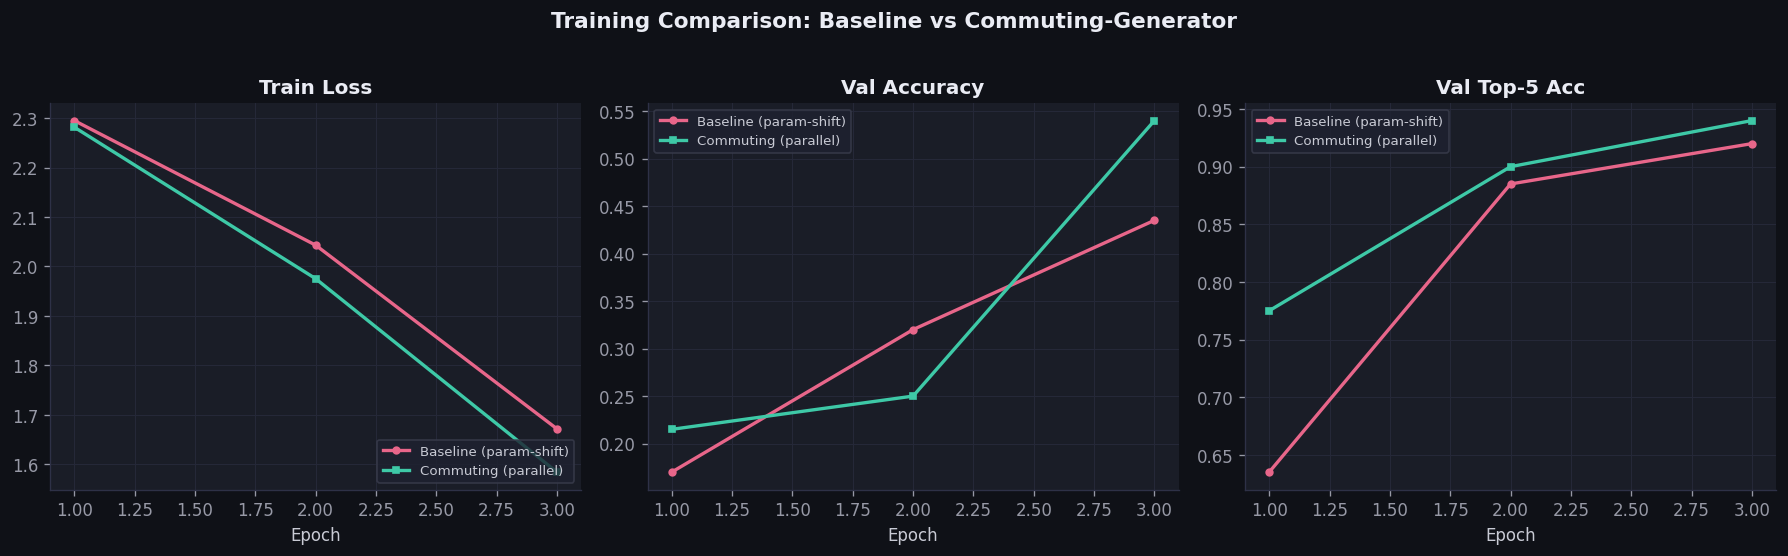

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Training Comparison: Baseline vs Commuting-Generator',
             fontsize=13, fontweight='bold', color='#EAECF4', y=1.02)

pairs = [
    ('train_loss', 'Train Loss',      'lower right'),
    ('val_acc',    'Val Accuracy',    'upper left'),
    ('val_top5',   'Val Top-5 Acc',   'upper left'),
]
for ax, (col, title, loc) in zip(axes, pairs):
    ax.plot(df_base['epoch'], df_base[col],
            color=C_BASELINE,  linewidth=2, marker='o', markersize=4,
            label='Baseline (param-shift)')
    ax.plot(df_comm['epoch'], df_comm[col],
            color=C_COMMUTING, linewidth=2, marker='s', markersize=4,
            label='Commuting (parallel)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(loc=loc, fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('results/comparison/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## 2. Circuit execution count comparison

This is the primary result.  The commuting method reduces global backward cost  
from `2 × n_gate_params` to `N_QUBITS` circuits per sample.

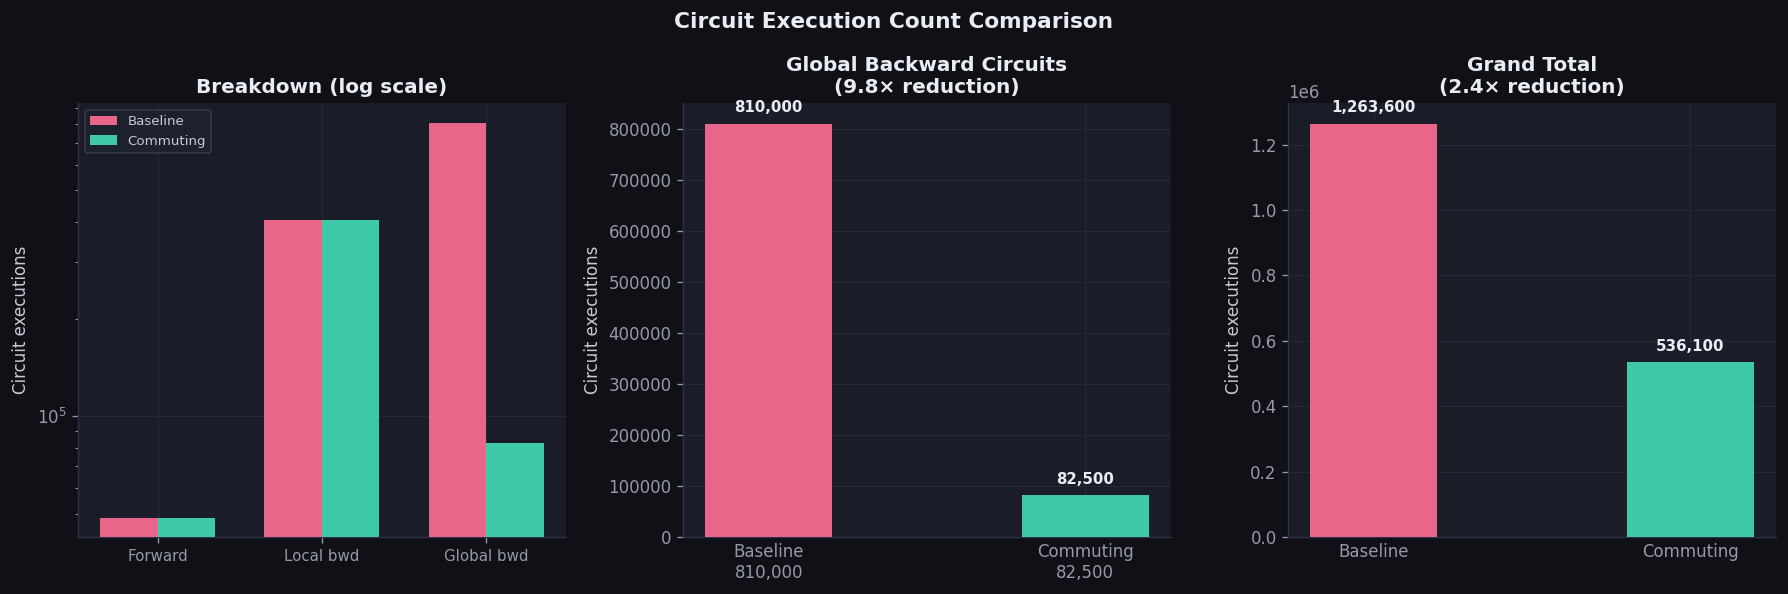

Global backward:  baseline=810,000  commuting=82,500  speedup=9.8×
Grand total:      baseline=1,263,600  commuting=536,100  speedup=2.4×


In [4]:
speedup_global = cb['global_bwd'] / max(cc['global_bwd'], 1)
speedup_total  = cb['grand_total'] / max(cc['grand_total'], 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Circuit Execution Count Comparison',
             fontsize=13, fontweight='bold', color='#EAECF4')

# Panel 1: breakdown (log scale)
ax = axes[0]
cats   = ['Forward', 'Local bwd', 'Global bwd']
base_v = [cb['fwd_total'], cb['local_bwd'], cb['global_bwd']]
comm_v = [cc['fwd_total'], cc['local_bwd'], cc['global_bwd']]
xi = np.arange(len(cats)); w = 0.35
ax.bar(xi-w/2, base_v, w, color=C_BASELINE,  label='Baseline',  edgecolor='none', zorder=3)
ax.bar(xi+w/2, comm_v, w, color=C_COMMUTING, label='Commuting', edgecolor='none', zorder=3)
ax.set_xticks(xi); ax.set_xticklabels(cats, fontsize=9)
ax.set_yscale('log'); ax.set_ylabel('Circuit executions')
ax.set_title('Breakdown (log scale)', fontweight='bold')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

# Panel 2: global backward only
ax = axes[1]
vals = [cb['global_bwd'], cc['global_bwd']]
cols = [C_BASELINE, C_COMMUTING]
labs = [f'Baseline\n{cb["global_bwd"]:,}', f'Commuting\n{cc["global_bwd"]:,}']
bars = ax.bar(labs, vals, color=cols, edgecolor='none', width=0.4, zorder=3)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
            f'{val:,}', ha='center', va='bottom', fontsize=9,
            fontweight='bold', color='#EAECF4')
ax.set_title(f'Global Backward Circuits\n({speedup_global:.1f}× reduction)',
             fontweight='bold')
ax.set_ylabel('Circuit executions')
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='x', length=0)

# Panel 3: grand total
ax = axes[2]
tots = [cb['grand_total'], cc['grand_total']]
bars2 = ax.bar(['Baseline', 'Commuting'], tots, color=cols,
               edgecolor='none', width=0.4, zorder=3)
for bar, val in zip(bars2, tots):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(tots)*0.02,
            f'{val:,}', ha='center', va='bottom', fontsize=9,
            fontweight='bold', color='#EAECF4')
ax.set_title(f'Grand Total\n({speedup_total:.1f}× reduction)',
             fontweight='bold')
ax.set_ylabel('Circuit executions')
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig('results/comparison/shot_efficiency.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Global backward:  baseline={cb["global_bwd"]:,}  '
      f'commuting={cc["global_bwd"]:,}  speedup={speedup_global:.1f}×')
print(f'Grand total:      baseline={cb["grand_total"]:,}  '
      f'commuting={cc["grand_total"]:,}  speedup={speedup_total:.1f}×')


## 3. Feature contributions

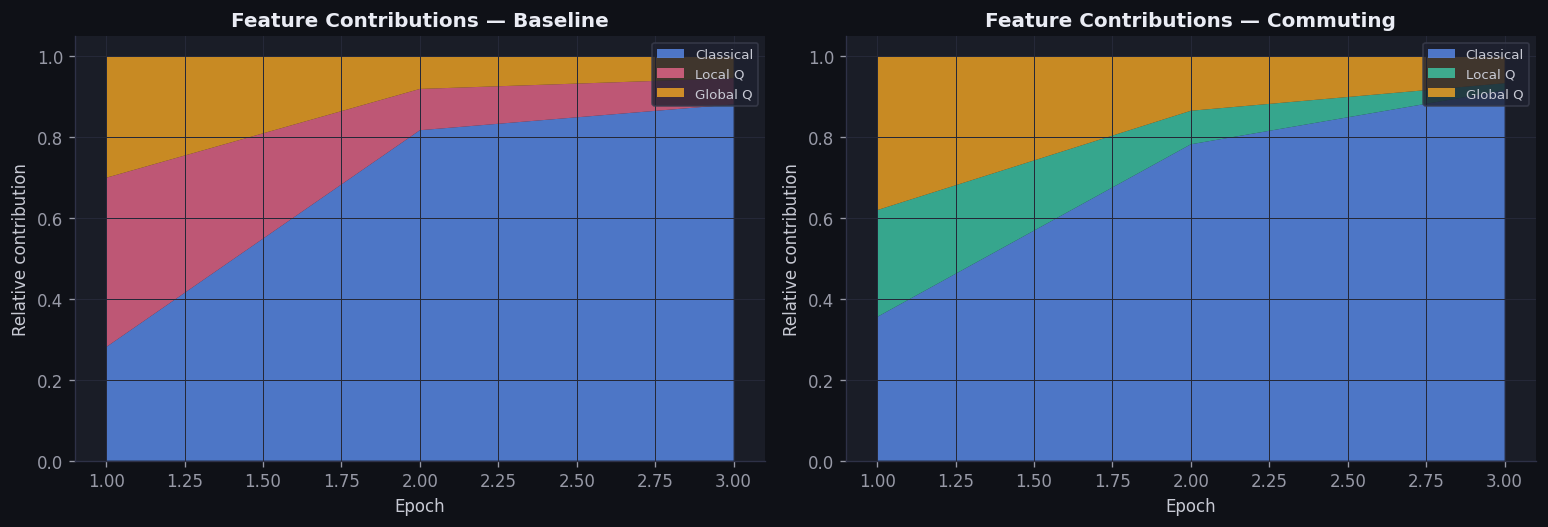

In [5]:
if 'feat_classical' in df_base.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, df, title, col in [
        (axes[0], df_base, 'Baseline',  C_BASELINE),
        (axes[1], df_comm, 'Commuting', C_COMMUTING),
    ]:
        ax.stackplot(df['epoch'],
                     df['feat_classical'], df['feat_local'], df['feat_global'],
                     labels=['Classical', 'Local Q', 'Global Q'],
                     colors=[C_BLUE, col, C_AMBER], alpha=0.8)
        ax.set_title(f'Feature Contributions — {title}', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Relative contribution')
        ax.legend(loc='upper right', fontsize=8)
        ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('results/comparison/feature_contributions.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('feat_classical column not found — skipping.')


## 4. Epoch wall-clock time

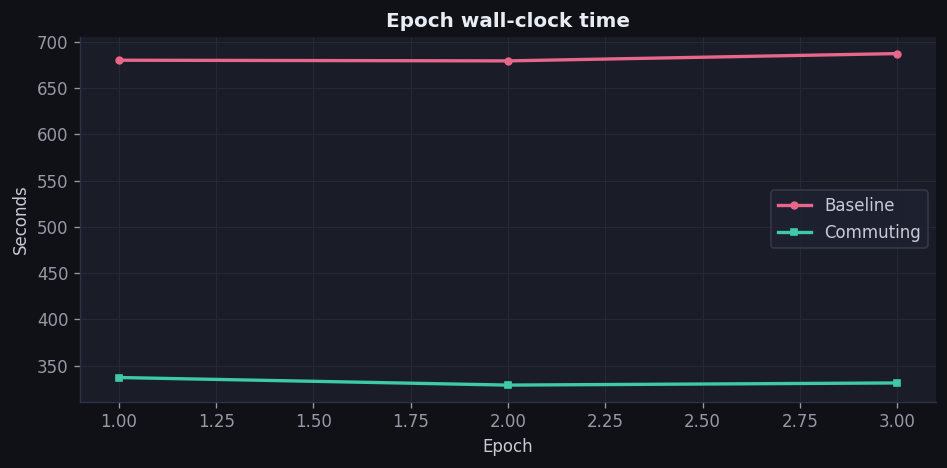

Avg epoch time — Baseline:  682.3s
Avg epoch time — Commuting: 332.4s
Wall-clock speedup: 2.05×


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_base['epoch'], df_base['epoch_time_s'],
        color=C_BASELINE,  linewidth=2, marker='o', markersize=4, label='Baseline')
ax.plot(df_comm['epoch'], df_comm['epoch_time_s'],
        color=C_COMMUTING, linewidth=2, marker='s', markersize=4, label='Commuting')
ax.set_title('Epoch wall-clock time', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Seconds')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/comparison/epoch_times.png', dpi=120, bbox_inches='tight')
plt.show()

avg_b = df_base['epoch_time_s'].mean()
avg_c = df_comm['epoch_time_s'].mean()
print(f'Avg epoch time — Baseline:  {avg_b:.1f}s')
print(f'Avg epoch time — Commuting: {avg_c:.1f}s')
if avg_c > 0:
    print(f'Wall-clock speedup: {avg_b/avg_c:.2f}×')


## 5. Full dashboard

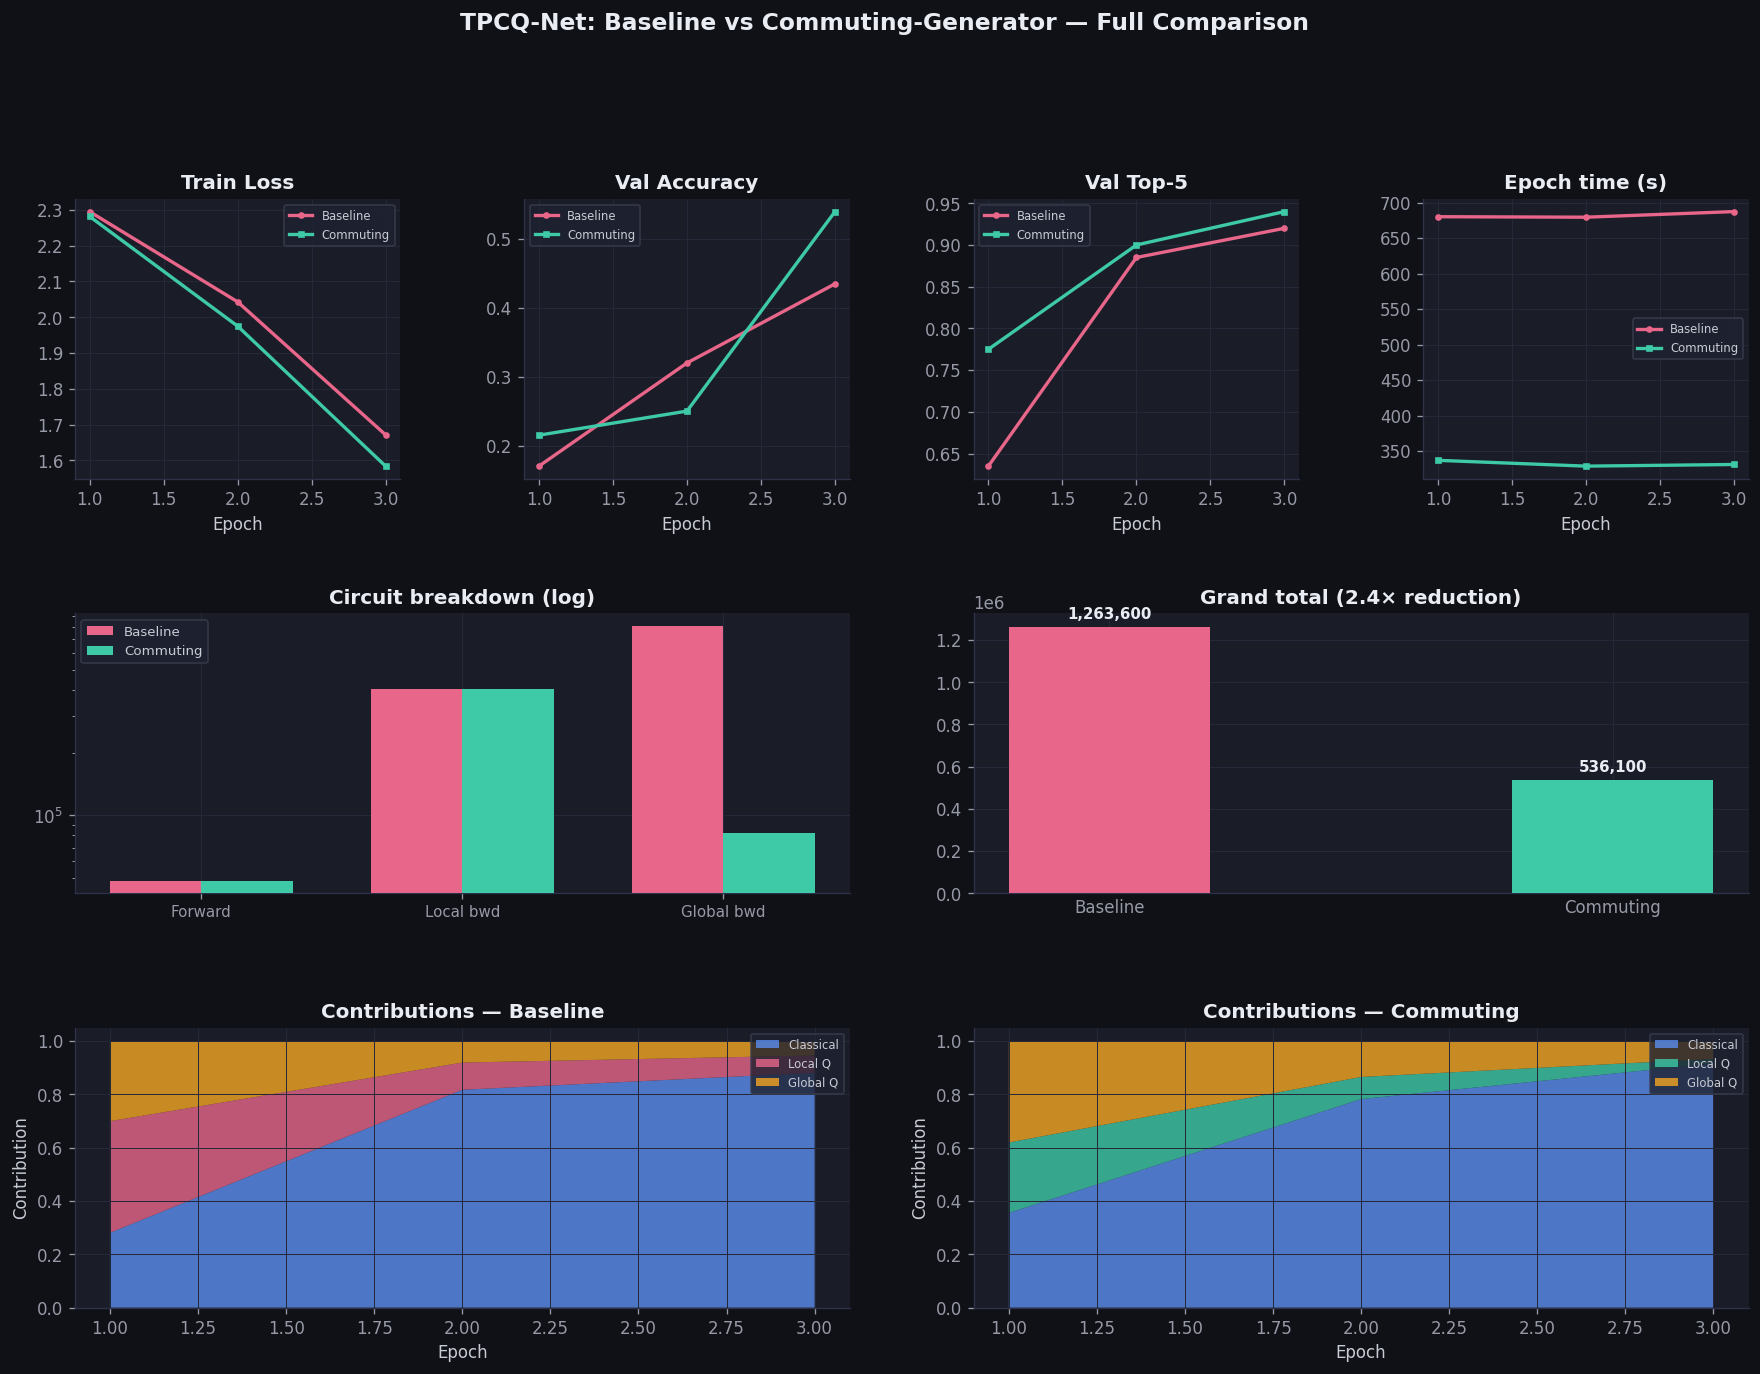

Saved results/comparison/full_dashboard.png


In [7]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.38)

# Row 0: training curves
for col_idx, (metric, ylabel) in enumerate([
    ('train_loss',    'Train Loss'),
    ('val_acc',       'Val Accuracy'),
    ('val_top5',      'Val Top-5'),
    ('epoch_time_s',  'Epoch time (s)'),
]):
    ax = fig.add_subplot(gs[0, col_idx])
    ax.plot(df_base['epoch'], df_base[metric],
            color=C_BASELINE,  marker='o', markersize=3, linewidth=2, label='Baseline')
    ax.plot(df_comm['epoch'], df_comm[metric],
            color=C_COMMUTING, marker='s', markersize=3, linewidth=2, label='Commuting')
    ax.set_title(ylabel, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)
    ax.spines[['top','right']].set_visible(False)

# Row 1: circuit breakdown + grand total
ax_circ = fig.add_subplot(gs[1, :2])
cats2   = ['Forward', 'Local bwd', 'Global bwd']
bv2     = [cb['fwd_total'], cb['local_bwd'], cb['global_bwd']]
cv2     = [cc['fwd_total'], cc['local_bwd'], cc['global_bwd']]
xi2 = np.arange(len(cats2)); w2 = 0.35
ax_circ.bar(xi2-w2/2, bv2, w2, color=C_BASELINE,  label='Baseline',  edgecolor='none', zorder=3)
ax_circ.bar(xi2+w2/2, cv2, w2, color=C_COMMUTING, label='Commuting', edgecolor='none', zorder=3)
ax_circ.set_xticks(xi2); ax_circ.set_xticklabels(cats2, fontsize=9)
ax_circ.set_yscale('log'); ax_circ.set_title('Circuit breakdown (log)', fontweight='bold')
ax_circ.legend(fontsize=8); ax_circ.spines[['top','right']].set_visible(False)

ax_tot = fig.add_subplot(gs[1, 2:])
ax_tot.bar(['Baseline', 'Commuting'],
           [cb['grand_total'], cc['grand_total']],
           color=[C_BASELINE, C_COMMUTING], edgecolor='none', width=0.4, zorder=3)
for i, (lbl, val) in enumerate([('Baseline', cb['grand_total']),
                                  ('Commuting', cc['grand_total'])]):
    ax_tot.text(i, val + max(cb['grand_total'],cc['grand_total'])*0.02,
                f'{val:,}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#EAECF4')
ax_tot.set_title(f'Grand total ({speedup_total:.1f}× reduction)', fontweight='bold')
ax_tot.spines[['top','right']].set_visible(False)
ax_tot.tick_params(axis='x', length=0)

# Row 2: feature contributions
if 'feat_classical' in df_base.columns:
    for col_idx, (df, title, col) in enumerate([
        (df_base, 'Baseline',  C_BASELINE),
        (df_comm, 'Commuting', C_COMMUTING),
    ]):
        ax = fig.add_subplot(gs[2, col_idx*2:(col_idx+1)*2])
        ax.stackplot(df['epoch'],
                     df['feat_classical'], df['feat_local'], df['feat_global'],
                     labels=['Classical', 'Local Q', 'Global Q'],
                     colors=[C_BLUE, col, C_AMBER], alpha=0.8)
        ax.set_title(f'Contributions — {title}', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Contribution')
        ax.legend(fontsize=7, loc='upper right')
        ax.spines[['top','right']].set_visible(False)

fig.suptitle('TPCQ-Net: Baseline vs Commuting-Generator — Full Comparison',
             fontsize=14, fontweight='bold', color='#EAECF4', y=1.01)
plt.savefig('results/comparison/full_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved results/comparison/full_dashboard.png')


## 6. Summary table

In [8]:
avg_b = df_base['epoch_time_s'].mean()
avg_c = df_comm['epoch_time_s'].mean()

W = 72
print('='*W)
print('  FINAL NUMERICAL SUMMARY'.center(W))
print('='*W)
fmt = '  {:<40} {:>14} {:>14}'
print(fmt.format('Metric', 'Baseline', 'Commuting'))
print('─'*W)
print(fmt.format('Best val accuracy',
                 f"{summ_base['best_acc']:.4f}",
                 f"{summ_comm['best_acc']:.4f}"))
print(fmt.format('Global bwd circuits (full run)',
                 f"{cb['global_bwd']:,}",
                 f"{cc['global_bwd']:,}"))
print(fmt.format('Grand total circuits',
                 f"{cb['grand_total']:,}",
                 f"{cc['grand_total']:,}"))
print(fmt.format('Global bwd speedup',   '1.0×', f'{speedup_global:.1f}×'))
print(fmt.format('Grand total speedup',  '1.0×', f'{speedup_total:.1f}×'))
print(fmt.format('Avg epoch time (s)',   f'{avg_b:.1f}', f'{avg_c:.1f}'))
print(fmt.format('Wall-clock speedup',
                 '1.0×',
                 f'{avg_b/avg_c:.2f}×' if avg_c > 0 else 'n/a'))
print(fmt.format('Total wall-clock (s)',
                 f"{summ_base['wall_time_s']:.1f}",
                 f"{summ_comm['wall_time_s']:.1f}"))
print(fmt.format('Train samples',
                 str(summ_base.get('train_samples', '?')),
                 str(summ_comm.get('train_samples', '?'))))
print(fmt.format('N qubits',
                 str(summ_base['n_qubits']),
                 str(summ_comm['n_qubits'])))
print(fmt.format('Global gate params',
                 str(summ_base['n_gate_params_g']),
                 str(summ_comm['n_gate_params_g'])))
print(fmt.format('Global logical params',
                 str(summ_base['n_logical_params_g']),
                 str(summ_comm['n_logical_params_g'])))
if 'max_weight' in summ_comm:
    print(fmt.format('Max Pauli weight', '—', str(summ_comm['max_weight'])))
print('='*W)

delta_acc = abs(summ_base['best_acc'] - summ_comm['best_acc'])
print(f'\nKey result: {speedup_global:.1f}× fewer global backward circuits')
print(f'with accuracy delta of {delta_acc:.4f}  '
      f'({"similar" if delta_acc < 0.05 else "different"} accuracy).')
print(f'Theory: {2*summ_base["n_gate_params_g"]} circuits/sample → '
      f'{summ_comm["n_qubits"]} circuits/sample')


                         FINAL NUMERICAL SUMMARY                        
  Metric                                         Baseline      Commuting
────────────────────────────────────────────────────────────────────────
  Best val accuracy                                0.4350         0.5400
  Global bwd circuits (full run)                  810,000         82,500
  Grand total circuits                          1,263,600        536,100
  Global bwd speedup                                 1.0×           9.8×
  Grand total speedup                                1.0×           2.4×
  Avg epoch time (s)                                682.3          332.4
  Wall-clock speedup                                 1.0×          2.05×
  Total wall-clock (s)                             2047.0          997.1
  Train samples                                      2500           2500
  N qubits                                              3              3
  Global gate params                               

## 7. Save combined CSV

In [9]:
df_base_out = df_base.copy(); df_base_out['variant'] = 'baseline'
df_comm_out = df_comm.copy(); df_comm_out['variant'] = 'commuting'
df_combined = pd.concat([df_base_out, df_comm_out], ignore_index=True)
df_combined.to_csv('results/comparison/combined_log.csv', index=False)
print('Saved results/comparison/combined_log.csv')
print(df_combined.groupby('variant')[['val_acc','val_top5','epoch_time_s']].mean().round(4))


Saved results/comparison/combined_log.csv
           val_acc  val_top5  epoch_time_s
variant                                   
baseline    0.3083    0.8133      682.3200
commuting   0.3350    0.8717      332.3667
